In [ ]:
# =========================================
# 📚 IMPORT ALL REQUIRED LIBRARIES (TOP CELL)
# =========================================

# Data handling
import pandas as pd
import numpy as np

# Text processing
import re

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Models 
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report
# Save model
import joblib
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import random


In [ ]:
#LOAD DATASET

In [ ]:
# Load
data = pd.read_csv(
    "../datasets/tigrigna_translated_news_dataset(5).csv",
    encoding="utf-8-sig",   # 👈 IMPORTANT FIX
    sep=None,
    engine="python"
)

# Clean column names
data.columns = data.columns.str.strip()

# Inspect
print("Columns:", list(data.columns))

# Rename properly (adjust based on output)
data.columns = data.columns.str.replace('\ufeff', '', regex=True).str.strip()

data.rename(columns=lambda x: x.strip().lower(), inplace=True)

data.rename(columns={
    'tigrigna_translated_text': 'text',
    'label': 'label'
}, inplace=True)

print(data.columns)
print(data[['text']].head())

In [18]:
# ===============================
# 🧹 TEXT CLEANING FUNCTION
# ===============================

def clean_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    
    # Remove Tigrigna punctuation explicitly
    text = re.sub(r'[፡።፣፤፥፦]', '', text)
    
    # Remove English punctuation
    text = re.sub(r'[^\w\sሀ-፿]', '', text)
    
    # Normalize spaces
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()
    

data['clean_text'] = data['text'].apply(clean_text)

In [19]:
# ===============================
# 🧹 CLEAN LABELS (STRONG VERSION)
# ===============================

# Remove missing values early
data = data.dropna(subset=['text', 'label'])

# Convert label to numeric
data['label'] = pd.to_numeric(data['label'], errors='coerce')

# Drop invalid rows again
data = data.dropna(subset=['label'])

# Convert to int
data['label'] = data['label'].astype(int)

# Define X and y AFTER cleaning
X = data['text']
y = data['label']

print("Remaining NaN:", data['label'].isnull().sum())
print("Label values:", data['label'].unique())

Remaining NaN: 0
Label values: [1 0]


In [20]:
# ===============================
# 🔄 NORMALIZATION FUNCTION
# ===============================

def normalize_tigrigna(text):
    # Normalize similar characters
    text = text.replace("አ", "ኣ")
    text = text.replace("ሐ", "ሀ")
    return text


# Apply normalization
data['clean_text'] = data['clean_text'].apply(normalize_tigrigna)

In [21]:
# Tokenization function
def tokenize(text):
    return re.findall(r'[A-Za-z]+|[ሀ-፿]+', text)

# Apply tokenization
data['tokens'] = data['clean_text'].apply(tokenize)

# Stopwords
stopwords = set([
    "እዚ","እዩ","እቲ","ኣብ","ናብ","ን","ናይ",
    "ከም","ስለ","ካብ","ወይ","ምስ","ነቲ","ነዚ",
    "ኣብዚ","ኝ","ይኹን","እምበር","ዋላኳ",
    "ኮታስ","ብ","እዉን","ድማ","ከሎ","እዋን",
    "ነታ","እየ","እዮም","እውን","ግን","ከምዘሎ","ኣሎ"
])

# Clean tokens function
def clean_tokens(tokens):
    return [word for word in tokens if word not in stopwords]

# Apply stopword removal
data['tokens'] = data['tokens'].apply(clean_tokens)

# Join tokens into text
data['processed_text'] = data['tokens'].apply(lambda x: " ".join(x))

In [22]:
print(data['tokens'].iloc[1])

['ኣመሪካ', 'ብሰንኪ', 'ልዕሊ', 'ዘይመንግስታውያን', 'ትካላት', 'ዝተወሰነ', 'ቀይዲ', 'ንግብጺ', 'እትህቦ', 'ሓገዝ', 'ንምቁራጽ', 'ትመክር', 'ኣላ', 'ዋሽንግተን', 'ሮይተርስ', 'መንግስቲ', 'ግብጺ', 'ልዕሊ', 'ዘይመንግስታውያን', 'ትካላት', 'NGOs', 'ገደብ', 'ዝጥው', 'ሓድሽ', 'ሕጊ', 'ብምሕላፉ', 'ሰበስልጣን', 'ኣመሪካ', 'ንግብጺ', 'ዝወሃብ', 'ሓገዝ', 'ብከፊል', 'ንምቁራጽ', 'ይዝትዩ', 'ከምዘለዉ', 'ሓደ', 'ላዕለዋይ', 'በዓል', 'ስልጣን', 'ምምሕዳር', 'ረቡዕ', 'ገሊጹ', 'በዓል', 'ስልጣን', 'ንሮይተርስ', 'ዝሓበሮ', 'ጉዳይ', 'ዝምልከት', 'ራስዩ', 'recommendation', 'ፕረዚደንት', 'ዶናልድ', 'ትራምፕን', 'ናብቶም', 'ላዕለዎት', 'መራሕትን', 'ንምቕራብ', 'ክሳብ', 'ሕጂ', 'ስምምዕ', 'ኣይተበጽሀን', 'ግብጺ', 'ስጉምቲ', 'ብምውሳዳ', 'ኣመሪካ', 'ብወገና', 'ግቡእ', 'ምላሽ', 'ክትህብ', 'ከምዘለዋ', 'ስምዒት', 'ንግብጺ', 'ዝወሃብ', 'ሓገዝ', 'ንነዊሕ', 'ዘይትንከፍ', 'sacrosanct', 'ኮይኑ', 'ጸኒሑ', 'ግብጺ', 'ሓንቲ', 'ካብተን', 'ማእከላይ', 'ምብራቕ', 'ዘለዋ', 'ዋሽንግተን', 'ቀረባ', 'መሓዙት', 'ኮይና', 'ዓመታዊ', 'ቢልዮን', 'ዶላር', 'ወተሃደራዊ', 'ሓገዝን', 'ኣስታት', 'ሚልዮን', 'ዶላር', 'ቁጠባዊ', 'ሓገዝን', 'ኣመሪካ', 'ትረክብ', 'ስጉምቲ', 'ኣመሪካ', 'ዝመጽእ', 'ሓገዝ', 'ሓደጋ', 'ዘውድቖ', 'ደጋጊምና', 'ነጊርናዮም', 'ነይርና', 'ንሳቶም', 'ሰሚዖም', 'ኣይገበርዎን', 'ክብል', 'በዓል', 'ስልጣን', 'ገሊጹ', 'ሕጂ', 'ብኸመይ', 'ምላሽ', 'እንህብ', 'ንርኢ', '

In [23]:
print("እውን" in data['tokens'].iloc[1])
print("ከምዘሎ" in data['tokens'].iloc[1])

False
False


In [24]:

X = data['processed_text']
y = data['label']
print(data['processed_text'].iloc[1])

ኣመሪካ ብሰንኪ ልዕሊ ዘይመንግስታውያን ትካላት ዝተወሰነ ቀይዲ ንግብጺ እትህቦ ሓገዝ ንምቁራጽ ትመክር ኣላ ዋሽንግተን ሮይተርስ መንግስቲ ግብጺ ልዕሊ ዘይመንግስታውያን ትካላት NGOs ገደብ ዝጥው ሓድሽ ሕጊ ብምሕላፉ ሰበስልጣን ኣመሪካ ንግብጺ ዝወሃብ ሓገዝ ብከፊል ንምቁራጽ ይዝትዩ ከምዘለዉ ሓደ ላዕለዋይ በዓል ስልጣን ምምሕዳር ረቡዕ ገሊጹ በዓል ስልጣን ንሮይተርስ ዝሓበሮ ጉዳይ ዝምልከት ራስዩ recommendation ፕረዚደንት ዶናልድ ትራምፕን ናብቶም ላዕለዎት መራሕትን ንምቕራብ ክሳብ ሕጂ ስምምዕ ኣይተበጽሀን ግብጺ ስጉምቲ ብምውሳዳ ኣመሪካ ብወገና ግቡእ ምላሽ ክትህብ ከምዘለዋ ስምዒት ንግብጺ ዝወሃብ ሓገዝ ንነዊሕ ዘይትንከፍ sacrosanct ኮይኑ ጸኒሑ ግብጺ ሓንቲ ካብተን ማእከላይ ምብራቕ ዘለዋ ዋሽንግተን ቀረባ መሓዙት ኮይና ዓመታዊ ቢልዮን ዶላር ወተሃደራዊ ሓገዝን ኣስታት ሚልዮን ዶላር ቁጠባዊ ሓገዝን ኣመሪካ ትረክብ ስጉምቲ ኣመሪካ ዝመጽእ ሓገዝ ሓደጋ ዘውድቖ ደጋጊምና ነጊርናዮም ነይርና ንሳቶም ሰሚዖም ኣይገበርዎን ክብል በዓል ስልጣን ገሊጹ ሕጂ ብኸመይ ምላሽ እንህብ ንርኢ ኣለና ዘተ ብዛዕባ ምሉእ ምቁራጽ ሓገዝ ዘይኮነስ ብዛዕባ ምቕናስ ሓደ ክፋል ሓገዝ ጥራይ ምዃኑ ተሓቢሩ ሓድሽ ግብጺ ሕጊ ንጥፈታት ዘይመንግስታውያን ትካላት ልምዓታውን ማሕበራዊ ስራሓትን ጥራይ ክሕጸር ዝገብር ኮይኑ ሕጊ ዘይተገዝኡ ክሳብ ሓሙሽተ ዓመት ዝበጽሕ ማእሰርቲ መቕጻዕቲ ይጽበዮም ኣውጽእቲ ሕጊ ግብጺ ሕጊ ሃገራዊ ድሕነት ንምሕላው ኣገዳሲ ምዃኑ ይገልጹ መንግስቲ ግብጺ ንነዊሕ ንጉጅለታት ሰብኣዊ መሰላት ወጻኢ ገንዘብ ብምቕባል ናዕቢ ይዘርኡ ኣለዉ ክብል ክኸሶም ጸኒሑ ወርሒ ግንቦት ሕጊ ብፕረዚደንት ዓብደል ፋታሕ ኣልሲሲ ተፈሪሙ ወጸ ኣባላት ሰነድ ኣመሪካ ነቒፎምዎ ነይሮም ሰ

In [54]:
# ===============================
# ✂️ TRAIN-TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,stratify=y
)


In [55]:
assert y_train.isnull().sum() == 0, "Still contains NaN!"

In [56]:
print("y_train NaN:", y_train.isnull().sum())

y_train NaN: 0


In [57]:
print(X_train.shape)
print(X_test.shape)

(2401,)
(601,)


In [60]:
# ===============================
#TF-IDF (Term Frequency – Inverse Document Frequency)
# 🎯 DEFINE FEATURES AND LABEL
# ===============================



In [61]:

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))
print(X_train_vec.shape[0], len(y_train))
print(X_train_vec.shape)
print(X_test_vec.shape)

2401 2401
601 601
2401 2401
(2401, 5000)
(601, 5000)


In [ ]:
#MODEL TRAINING (Fake News Classifier) 

In [62]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9251247920133111
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       301
           1       0.94      0.91      0.92       300

    accuracy                           0.93       601
   macro avg       0.93      0.93      0.93       601
weighted avg       0.93      0.93      0.93       601



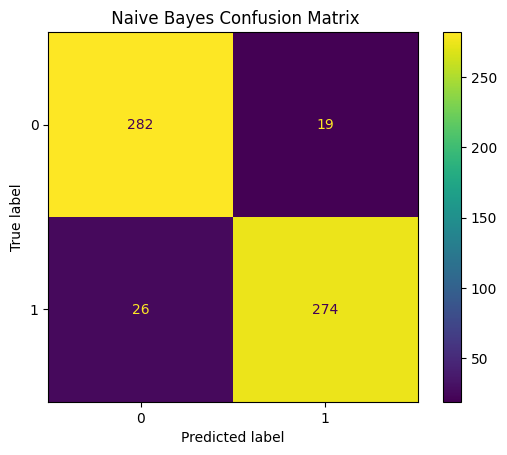

In [63]:
# ===============================
# 📊 CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(" Naive Bayes Confusion Matrix")
plt.show()

In [66]:
best_svm.fit(X_train_vec, y_train)
svm_pred = best_svm.predict(X_test_vec)

In [67]:
# ===============================
# 🤖 LOGISTIC REGRESSION
# ===============================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9484193011647255
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       301
           1       0.96      0.93      0.95       300

    accuracy                           0.95       601
   macro avg       0.95      0.95      0.95       601
weighted avg       0.95      0.95      0.95       601



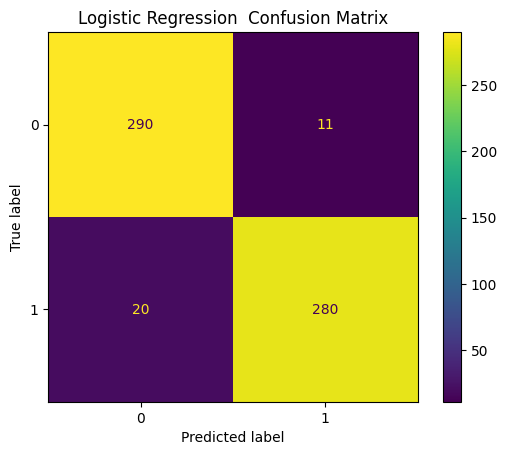

In [68]:
# ===============================
# 📊 CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Logistic Regression  Confusion Matrix")
plt.show()

In [69]:
param_grid = {
    'C': [0.1, 1, 5, 10]
}

grid = GridSearchCV(
   LinearSVC(class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train_vec, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10}
Best Score: 0.9583515397419893


In [70]:
# ===============================
# 🤖 SVM MODEL (STRONG MODEL)
# ===============================
best_svm = grid.best_estimator_

svm_pred = best_svm.predict(X_test_vec)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.961730449251248
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       301
           1       0.97      0.96      0.96       300

    accuracy                           0.96       601
   macro avg       0.96      0.96      0.96       601
weighted avg       0.96      0.96      0.96       601



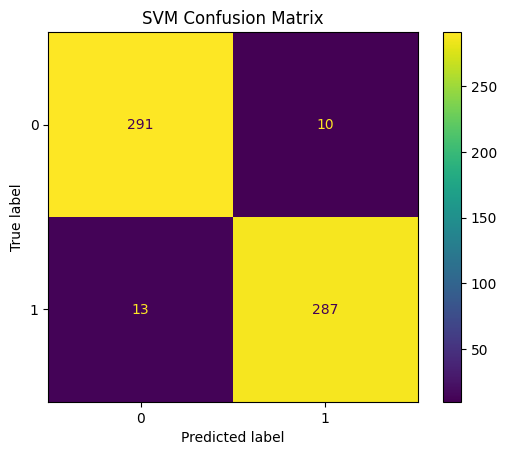

In [71]:
# ===============================
# 📊 CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("SVM Confusion Matrix")
plt.show()

In [89]:
print("\nNaive Bayes Report:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))
print("\nLogistic Regression Report:",accuracy_score(y_test,lr_pred))
print(classification_report(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


Naive Bayes Report: 0.9251247920133111
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       301
           1       0.94      0.91      0.92       300

    accuracy                           0.93       601
   macro avg       0.93      0.93      0.93       601
weighted avg       0.93      0.93      0.93       601


Logistic Regression Report: 0.9484193011647255
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       301
           1       0.96      0.93      0.95       300

    accuracy                           0.95       601
   macro avg       0.95      0.95      0.95       601
weighted avg       0.95      0.95      0.95       601

SVM Accuracy: 0.961730449251248
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       301
           1       0.97      0.96      0.96       300

    accuracy                           0.96       601
   macro

In [90]:
scores = cross_val_score(best_svm, X_train_vec, y_train, cv=5)

print("SVM Cross Validation Accuracy:", scores.mean())

SVM Cross Validation Accuracy: 0.9595980595980595


In [91]:
# ===============================
# 🔮 PREDICTION FUNCTION
# ===============================

def predict_news(text):
    text = clean_text(text)
    text = normalize_tigrigna(text)
    tokens = tokenize(text)
    tokens = clean_tokens(tokens)
    processed = " ".join(tokens)

    word_vec = word_vectorizer.transform([processed])
    char_vec = char_vectorizer.transform([processed])

    from scipy.sparse import hstack
    final_vec = hstack([word_vec, char_vec])

    prediction = best_svm.predict(final_vec)[0]

    if prediction == 1:
        return "🟢 REAL NEWS"
    else:
        return "🔴 FAKE NEWS"

In [93]:
# ===============================
# 🔍 RANDOM TEST FROM DATASET
# ===============================


def predict_news(text):
    processed = text
    
    # If you still want preprocessing:
    tokens = tokenize(text)
    tokens = clean_tokens(tokens)
    processed = " ".join(tokens)

    vec = vectorizer.transform([processed])

    pred = best_svm.predict(vec)

    return "REAL" if pred[0] == 1 else "FAKE"

In [98]:
for i in range(5):
    idx = random.randint(0, len(data)-1)

    text = data['processed_text'].iloc[idx]
    actual = data['label'].iloc[idx]

    prediction = predict_news(text)

    print("\n📝 TEXT:", text[:1000], "...")
    print("✅ ACTUAL:", "REAL" if actual == 1 else "FAKE")
    print("🤖 PREDICTED:", prediction)


📝 TEXT: ሰሙን ኣፈጉባኤ ቤት ምኽሪ ፖል ራያን Paul Ryan ገለ ሪፓብሊካን መሳርሕቱ ኾይኑ ዶናልድ ትራምፕ ብቭላድሚር ፑቲን ይኽፈል Trump is on Putins payroll ብምባል ክዋዘዩ ከለዉ ዝተቐርጸ ድምጺ ብምውጽኡ ዋሽንግተን ዓቢ ምንቅጥቃጥ ፈጢሩ ራያን በዚ ኣጋጣሚ ኣዝዩ ምስንባዱ ዝተላዕለ ካልእ እንታይ ተወሳኺ ጉድ ክወጽእ ይኸውን ብዝብል ስግኣት ተዋሒጡ ይርከብ ፖል ራያን ምስቲ ዓቃባዊ ራድዮ መቕረቢ ሂው ሂዊት Hugh Hewitt ዝገበሮ ዝርርብ ቅድሚ ዓመት ዝተገብረ ኣኼባ ብምስጢር ዝተቐርጸ ድምጺ ሕጂ ምውጽኡ ዘገርም ነገር bizarre thing ምዃኑ ገሊጹ ራያን ዝተባህለ ነገር ዋዛ joke ዝነበረ ክገልጽ እኳ እንተፈተነ ምስጢራዊ ቀርጺ ግና ንደገፍቲ ትራምፕን ንሪፓብሊካን ፓርቲን ከቢድ ሕፍረት ኣውዲቕዎም ሂዊት ድምጺ ዘውጽኦ ሰብ ኢቫን ማክሙሊን Evan McMullin ይኸውን ዝብል ጥርጣረ እንተቕረበ እኳ ራያን ግና ብንጹር ስም ምጥቃስ ተቖጢቡ ብዛዕባ ፖለቲካዊ ምስሕሓብን ተዛመድቲ ሓቅታትን ዝስዕቡ ስታቲስቲክስ ምጥቃስ ይከኣል ዝተገብረ The Washington Post ጸብጻብ ዘርእዮ ምስጢራዊ ዝርርብ ሰነ ትራምፕ ሕጹይ ሪፓብሊካን ዝኸውን ድሕሪ ሓደ ወርሒ ዝተገብረ ኣብቲ ዝተገብረ Gallup መጽናዕቲ ዘርእዮ ዓሰርተ ሓሙሽተ ሚኢታዊ ዝኾኑ ኣመሪካውያን ጥራይ ንፑቲን ብኣወንታ ዝርእይዎ ነይሮም መንጎ መራሕቲ ሪፓብሊካንን ትራምፕን ዝነበረ ኣረኣእያ ፍልልይ ዘርእይ ብተወሳኺ ሪፓብሊካን መሪሕነት ኣባል ዝነበረ ኬቨን ማካርቲ Kevin McCarthy ኣብቲ ቀርጺ ክልተ ሰባት ጥራይ ፑቲን ዝኸፍሎም ዝመስሉኒ ሮራባከርን ትራምፕን Theres two people I think Putin pays Rohrabacher and Trump ክብል ተሰሚዑ ዋላ እኳ ዋዛ እን

In [99]:
# ===============================
# ❌ SHOW WRONG PREDICTIONS
# ===============================

wrong = []

for i in range(len(X_test)):
    pred = best_svm.predict(X_test_vec[i])
    actual = y_test.iloc[i]

    if pred != actual:
        wrong.append(i)

print("Total wrong predictions:", len(wrong))

Total wrong predictions: 23


In [100]:
for i in wrong[:5]:
    print("\n📝 TEXT:", X_test.iloc[i][:200])
    print("❌ ACTUAL:", y_test.iloc[i])
    print("🤖 PREDICTED:", best_svm.predict(X_test_vec[i])[0])


📝 TEXT: ዋሽንግተን ሮይተርስ ቸክ ተላኢኹ ድሕሪ ሓደ ኣቦ ዝተቐትለ ኣመሪካ ሰራዊት ሳርጀንት ፕረዚደንት ዶናልድ ትራምፕ ዝኣተዎ ልግስና ዝመልኦ ቃል ኣይተተግበረን ምባሉ ዋይት ሃውስ ረቡዕ ዝሃቦ መልሲ ክሪስ ባልድሪጅ ንጋዜጣ ዋሽንግተን ፖስት Washington Post ዝገለጾ ትራምፕ ብሰንኪ ሓደ ኣፍጋኒስታን ፖሊስ መኮነን ወር
❌ ACTUAL: 1
🤖 PREDICTED: 0

📝 TEXT: ሰነተር ጆን ኮርኒን ልዕሊ ሙለር ወረርቲ ቃላት ተጠቒሙ ሴኔት ሪፓብሊካን መራሒ ጆን ኮርኒን John Cornyn ሮበርት ሙለር ንትካሉ ወገንተኛታት partisans ከጽሪ ዝግባእ ገሊጹ ግጭት ቀዳማይ ዓቃቤ ሕጊ ኤሪክ ሆልደር Eric Holder ሪፓብሊካን ንሙለር ንከይሰጉዎም መጠንቀቕታ ድሕሪ ምሃቡ ኮርኒን ሓሳብ ብምንዓ
❌ ACTUAL: 0
🤖 PREDICTED: 1

📝 TEXT: ዋሽንግተን ሮይተርስ ሪፓብሊካውያን ኣባላት ባይቶ ፕረዚደንት ዶናልድ ትራምፕ ንነዊሕ ዘማርረሉ ዝነበረ ፖለቲካዊ ጉዳያት ንምምርማር ሰሉስ ሓዱሽ መርመራታት ጀሚሮም ኣለዉ ብቤት ጽሕፈት መርመራ ፌደራል ዝተኻየደ መርመራ መልእኽቲ ኣየር ኢመይል ሂላሪ ክሊንተንን ንሩስያ ዝተሸጠ ኣመሪካ ጸዓት ማዕድን ዩራኒየም ጉዳይን ዘጠቓ
❌ ACTUAL: 1
🤖 PREDICTED: 0

📝 TEXT: ትሬንተን ሮይተርስ ኣመሓዳሪ ኒው ጀርሲ ክሪስ ክሪስቲ Chris Christie መንግስቲ እታ ክፍለሃገር ተዓጽዩ ዘለወሉ ንበይኑን ስድራቤቱን ዝተዓጽወ ህዝባዊ ወርሒባሕሪ beach ግዜ ከሕልፍ ምርኣዩ ልዕሊ ነበርቲ እታ ክፍለሃገር ዓቢ ቁጥዐ ፈጢሩ ቀንዲ ነጥብታት ዜና ክሪስቲ ምላሽ ምምሕዳር ብሰንኪ ባጀት ምስሕሓብ ንመ
❌ ACTUAL: 0
🤖 PREDICTED: 1

📝 TEXT: ምርመራ ኤፍቢኣይ FBI ልዕሊ ሂላሪ ክሊንተን ክልተ ሪፓብሊካን ኣባላ

In [101]:
scores = cross_val_score(best_svm, X_train_vec, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average:", scores.mean())

Cross-validation scores: [0.96465696 0.95833333 0.96458333 0.93958333 0.97083333]
Average: 0.9595980595980595


In [102]:
# ===============================
# 💾 SAVE MODEL
# ===============================
joblib.dump(best_svm, "../models/fake_news_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']